从提供的 $\mathrm{d}n / \mathrm{d}M$ 的列表（单位时 $M_{\odot}^{-1 }\mathrm{Mpc}^{-3 }$），使用二维插值的办法，给出任意 $M,z$ 时的质量函数 $\mathrm{d} n /\mathrm{d}M(M,z)$ .

In [1]:
import numpy as np
data = np.loadtxt('./dn_dM.txt', skiprows=1)

print(type(data))
print(data[0:6])
print('============================================')
print(data[1000:1006])

<class 'numpy.ndarray'>
[[4.00000000e+00 1.00000000e+05 6.96620846e-02]
 [4.00000000e+00 1.02329299e+05 6.66306234e-02]
 [4.00000000e+00 1.04712855e+05 6.37310506e-02]
 [4.00000000e+00 1.07151931e+05 6.09576806e-02]
 [4.00000000e+00 1.09647820e+05 5.83050509e-02]
 [4.00000000e+00 1.12201845e+05 5.57679145e-02]]
[[4.00000000e+00 1.00000000e+15 6.80628809e-40]
 [4.10000000e+00 1.00000000e+05 7.02713469e-02]
 [4.10000000e+00 1.02329299e+05 6.72121499e-02]
 [4.10000000e+00 1.04712855e+05 6.42860969e-02]
 [4.10000000e+00 1.07151931e+05 6.14874462e-02]
 [4.10000000e+00 1.09647820e+05 5.88106814e-02]]


In [2]:
# 统计质量为data[0, 0]的行数，即每个z对应的M采样点的数量
n_mass = np.sum(np.isclose(data[:, 0], data[0, 0]))
print(type(n_mass))
print(n_mass)

<class 'numpy.int64'>
1001


In [3]:
# 网格化
z_grid = data[::n_mass, 0] # 每n_mass行取一个z值（第0列），形成z_grid
log1pz_grid = np.log(1.0 + z_grid)
M_grid = data[:n_mass, 1] # 取前n_mass行的第1列（质量），形成M_grid
logM_grid = np.log(M_grid)
dn_dM_grid = data[:, 2].reshape(-1, n_mass) # 将第2列（dn/dM）重塑为二维数组，每行对应一个z值，每列对应一个质量值

print('log(1+z) range:', log1pz_grid[0], '->', log1pz_grid[-1], ', number of z points =', len(log1pz_grid))
print('log(M) range  :', logM_grid[0], '->', logM_grid[-1], ', number of M points =', len(logM_grid))
print('grid shape    :', dn_dM_grid.shape)

log(1+z) range: 1.6094379124341003 -> 3.713572066704315 , number of z points = 361
log(M) range  : 11.512925464970229 -> 34.538776394910684 , number of M points = 1001
grid shape    : (361, 1001)


In [4]:
# 二维插值
from scipy.interpolate import RegularGridInterpolator

# 二维插值函数
dn_dM_interp = RegularGridInterpolator(
    (log1pz_grid, logM_grid),
    dn_dM_grid,
    method = 'linear',
    # method = 'cubic',
    bounds_error = False,
    fill_value = np.nan,
)

def dn_dM_from_log(log1pz, logM):
    # 使用广播机制将输入的log1pz和logM扩展为相同形状的数组，然后进行插值
    log1pz_arr, logM_arr = np.broadcast_arrays(
        np.asarray(log1pz, dtype=float),
        np.asarray(logM, dtype=float)
    )
    points = np.column_stack((log1pz_arr.ravel(), logM_arr.ravel()))
    values = dn_dM_interp(points).reshape(log1pz_arr.shape)
    # 如果输入是标量，则返回标量，否则返回数组
    if values.shape == ():
        return float(values)
    return values

# 定义一个包装函数，接受z和M作为输入，计算log(1+z)和log(M)，然后调用dn_dM_from_log进行插值
def dn_dM(z, M):
    z_arr, M_arr = np.broadcast_arrays(np.asarray(z, dtype=float), np.asarray(M, dtype=float))
    if np.any(M_arr <= 0.0):
        raise ValueError('M must be > 0 for log(M).')
    if np.any(z_arr <= -1.0):
        raise ValueError('z must be > -1 for log(1+z).')
    return dn_dM_from_log(np.log(1.0 + z_arr), np.log(M_arr))

# test
z = 4.13
M = 1.2e5
print(f'dn_dM(z={z}, M={M}) = {dn_dM(z, M)}')


dn_dM(z=4.13, M=120000.0) = 0.04952477196529975


In [5]:
# 数值检查
zz, mm = np.meshgrid(z_grid, M_grid, indexing='ij')
pred_grid = dn_dM(zz, mm)
abs_err = np.abs(pred_grid - dn_dM_grid)
rel_err = np.zeros_like(abs_err)
mask = dn_dM_grid != 0.0
rel_err[mask] = abs_err[mask] / np.abs(dn_dM_grid[mask])
print('max_abs_err =', np.max(abs_err))
print('max_rel_err =', np.max(rel_err))

max_abs_err = 0.0
max_rel_err = 0.0


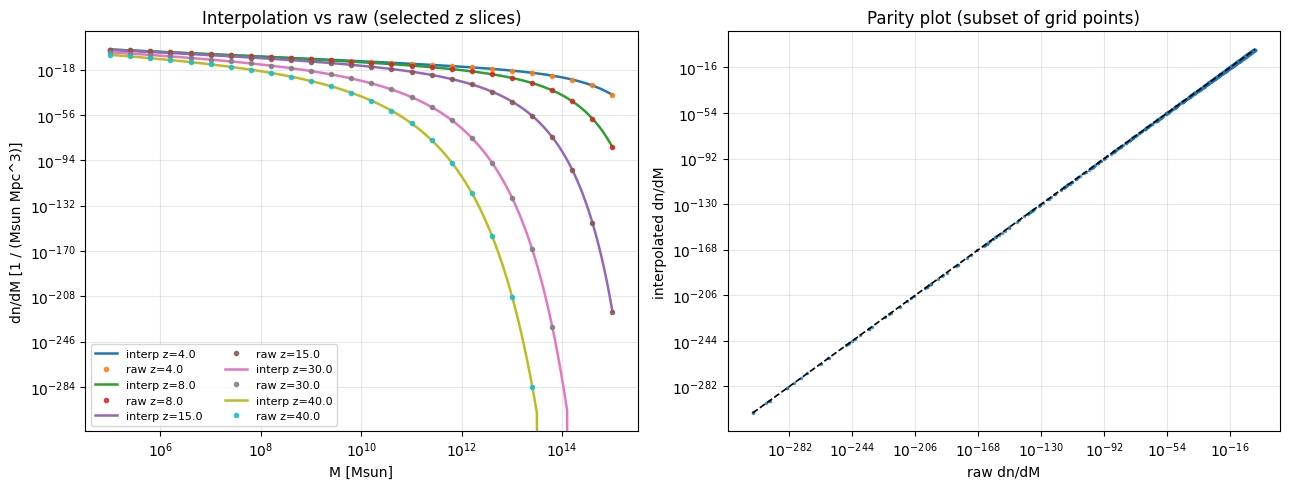

In [6]:
# 比较插值结果和原始数据
import matplotlib.pyplot as plt

z_samples = [4.0, 8.0, 15.0, 30.0, 40.0]
M_dense = np.exp(np.linspace(logM_grid[0], logM_grid[-1], 500))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for z0 in z_samples:
    iz = int(np.argmin(np.abs(z_grid - z0)))
    z_use = z_grid[iz]
    raw = dn_dM_grid[iz, :]
    fit = dn_dM(z_use, M_dense)
    axes[0].loglog(M_dense, fit, lw=1.8, label=f'interp z={z_use:.1f}')
    axes[0].loglog(M_grid[::40], raw[::40], 'o', ms=3, alpha=0.85, label=f'raw z={z_use:.1f}')

axes[0].set_xlabel('M [Msun]')
axes[0].set_ylabel('dn/dM [1 / (Msun Mpc^3)]')
axes[0].set_title('Interpolation vs raw (selected z slices)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3, which='both')

zz_sub, mm_sub = np.meshgrid(z_grid[::20], M_grid[::20], indexing='ij')
raw_sub = dn_dM_grid[::20, ::20]
fit_sub = dn_dM(zz_sub, mm_sub)
x = raw_sub.ravel()
y = fit_sub.ravel()
positive = (x > 0) & (y > 0)
x = x[positive]
y = y[positive]
axes[1].loglog(x, y, '.', ms=3, alpha=0.7)
if x.size == 0:
    raise ValueError('No positive points for log-log parity plot; check dn_dM argument order and data range.')
lo = min(np.min(x), np.min(y))
hi = max(np.max(x), np.max(y))
axes[1].loglog([lo, hi], [lo, hi], 'k--', lw=1.2)
axes[1].set_xlabel('raw dn/dM')
axes[1].set_ylabel('interpolated dn/dM')
axes[1].set_title('Parity plot (subset of grid points)')
axes[1].grid(alpha=0.3, which='both')

fig.tight_layout()
plt.show()

